In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
import warnings
warnings.simplefilter("ignore")

In [3]:
df = pd.read_csv("./carros.csv")
df

,kms,precio
0,6048,1385956
1,11825,1297582
2,20000,1000000
3,21048,1284844
4,21549,685300
5,21613,1342000
6,24184,1207484
7,25000,1005000
8,27027,655402
9,27863,814000


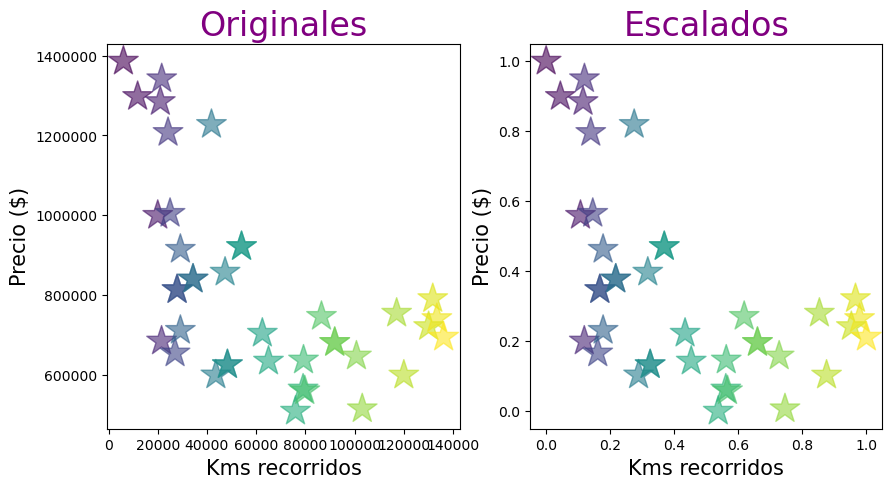

In [6]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,2,1)
ax.scatter(df['kms'],df["precio"], marker="*",
          s=500, c=range(df["kms"].size), alpha=0.6)

ax.set_title("Originales", size=24, color="purple")
ax.set_ylabel("Precio ($)", size=15)
ax.set_xlabel("Kms recorridos", size=15)
ax.ticklabel_format(style="plain")

escala_kms = preprocessing.MinMaxScaler()
escala_precio = preprocessing.MinMaxScaler()
kms = escala_kms.fit_transform(df["kms"].values.reshape(-1,1))
precio = escala_precio.fit_transform(df["precio"].values.reshape(-1,1))

ax = fig.add_subplot(1,2,2)
ax.scatter(kms,precio, marker="*",
          s=500, c=range(kms.size),alpha=0.6)

ax.set_title("Escalados", size=24, color="purple")
ax.set_ylabel("Precio ($)", size = 15)
ax.set_xlabel("Kms recorridos", size = 15)
ax.ticklabel_format(style="plain")

plt.show()

In [7]:
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(kms, precio)

kms_instancia = escala_kms.transform([[20000]])
precio_instancia = knn.predict(kms_instancia)
escala_precio.inverse_transform(precio_instancia)

array([[990048.]])

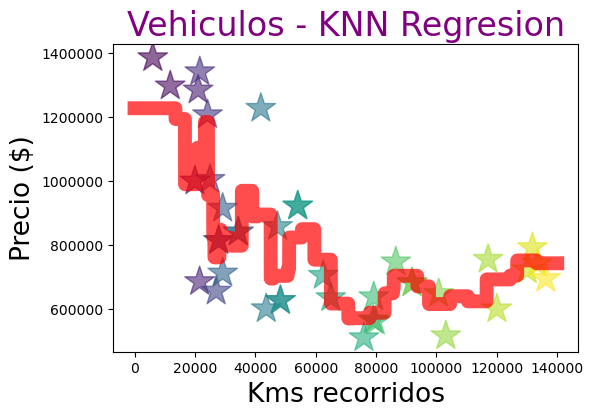

In [10]:
#Valor original 10
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(kms, precio)
kms_instancias = escala_kms.transform(np.arange(140000).reshape(-1,1))
precio_instancias = knn.predict(kms_instancias)
todas = escala_precio.inverse_transform(precio_instancias)
todas = todas.reshape(1,-1)

fig = plt.figure(figsize=(6,4))
plt.plot(np.arange(140000),todas.reshape(1,-1)[0],
        linewidth=10, color="red", alpha=0.7)
plt.scatter(df["kms"], df["precio"], marker="*",
           s=500, c=range(df["kms"].size), alpha=0.6)

plt.title("Vehiculos - KNN Regresion", size=24, color="purple")
plt.ylabel("Precio ($)", size=19)
plt.xlabel("Kms recorridos", size=19)
plt.ticklabel_format(style="plain")
plt.show()